<a href="https://www.kaggle.com/code/lalit7881/apple-stock-data-1980-2026?scriptVersionId=306808492" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_institutional_ownership.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_technical_indicators.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_splits.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_income_statement.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_dividends.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_balance_sheet.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_master_dataset.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_summary.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/aapl_cash_flow.csv
/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-f

## Loading dataset

In [2]:
import os

# Base path
base_path = "/kaggle/input/datasets/anadiskt/apple-aapl-full-stock-financial-dataset-1980-2026/"

# Load all datasets into dictionary
datasets = {}

for file in os.listdir(base_path):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        datasets[name] = pd.read_csv(base_path + file)

# Check loaded datasets
print(datasets.keys())

dict_keys(['aapl_institutional_ownership', 'aapl_technical_indicators', 'aapl_splits', 'aapl_income_statement', 'aapl_dividends', 'aapl_balance_sheet', 'aapl_master_dataset', 'aapl_summary', 'aapl_cash_flow', 'aapl_quarterly_financials', 'aapl_historical_data', 'aapl_stock_prices'])


In [3]:
for name, df in datasets.items():
    print(f"\n{name.upper()} DATASET")
    print("-"*50)
    print(df.head())
    print(df.info())
    print(df.describe())


AAPL_INSTITUTIONAL_OWNERSHIP DATASET
--------------------------------------------------
  Date Reported                         Holder  pctHeld      Shares  \
0    2025-12-31             Vanguard Group Inc   0.0972  1426283914   
1    2025-12-31                 Blackrock Inc.   0.0786  1154665731   
2    2025-12-31       State Street Corporation   0.0411   604056505   
3    2025-12-31  Geode Capital Management, LLC   0.0244   358032517   
4    2025-12-31                       FMR, LLC   0.0209   307397264   

          Value  pctChange  
0  356485404947     0.0192  
1  288597155625     0.0073  
2  150977884334     0.0110  
3   89486648173     0.0052  
4   76830872914     0.0137  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date Reported  10 non-null     object 
 1   Holder         10 non-null     object 
 2   pctHeld        10 non-null  

In [4]:
for name, df in datasets.items():
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')

In [5]:
for name, df in datasets.items():
    print(f"{name} Missing Values:\n", df.isnull().sum())
    
    # Fill numeric with median
    df.fillna(df.median(numeric_only=True), inplace=True)
    
    # Fill categorical with mode
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

aapl_institutional_ownership Missing Values:
 Date Reported    0
Holder           0
pctHeld          0
Shares           0
Value            0
pctChange        0
dtype: int64
aapl_technical_indicators Missing Values:
 Unnamed: 0    0
Date          5
Open          5
High          5
Low           5
Close         5
Adj Close     5
Volume        5
dtype: int64
aapl_splits Missing Values:
 Date      0
Splits    0
dtype: int64
aapl_income_statement Missing Values:
 Unnamed: 0                                                    0
Tax Effect Of Unusual Items                                   1
Tax Rate For Calcs                                            1
Normalized EBITDA                                             1
Net Income From Continuing Operation Net Minority Interest    1
Reconciled Depreciation                                       1
Reconciled Cost Of Revenue                                    1
EBITDA                                                        1
EBIT                      

In [6]:
stock_df = datasets['aapl_stock_prices']

# Standardize column names
stock_df.columns = stock_df.columns.str.strip().str.lower()

# Convert date column
stock_df['date'] = pd.to_datetime(stock_df['date'])

# Sort by date
stock_df = stock_df.sort_values(by='date')

# Feature Engineering
stock_df['daily_return'] = stock_df['close'].pct_change()
stock_df['ma50'] = stock_df['close'].rolling(50).mean()
stock_df['ma200'] = stock_df['close'].rolling(200).mean()

stock_df.head()

,date,open,high,low,close,volume,daily_return,ma50,ma200
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN,NaN,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,-0.052170,NaN,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,-0.073398,NaN,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,0.024751,NaN,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,0.028992,NaN,NaN


## EDA

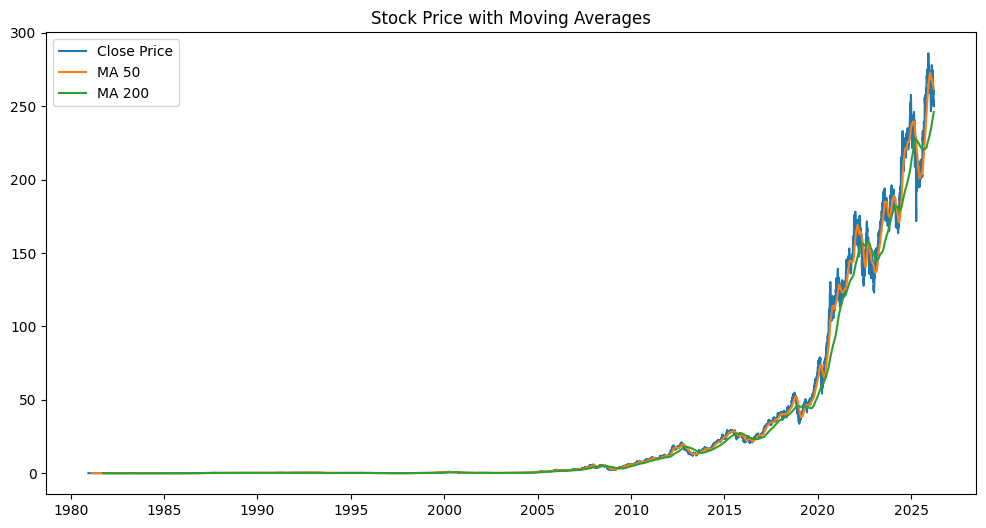

In [7]:
plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['close'], label='Close Price')
plt.plot(stock_df['date'], stock_df['ma50'], label='MA 50')
plt.plot(stock_df['date'], stock_df['ma200'], label='MA 200')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

In [8]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=stock_df['date'],
    open=stock_df['open'],
    high=stock_df['high'],
    low=stock_df['low'],
    close=stock_df['close']
)])

fig.update_layout(title="AAPL Candlestick Chart")
fig.show()

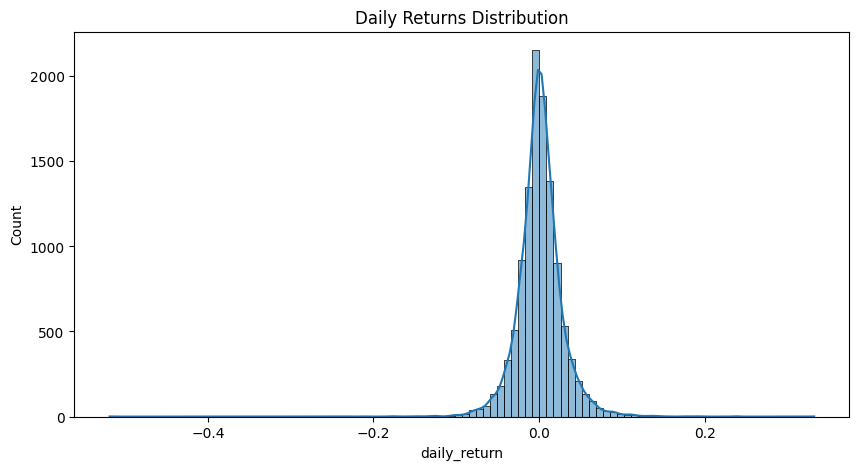

In [9]:
stock_df['daily_return'] = stock_df['close'].pct_change()

plt.figure(figsize=(10,5))
sns.histplot(stock_df['daily_return'], bins=100, kde=True)
plt.title("Daily Returns Distribution")
plt.show()

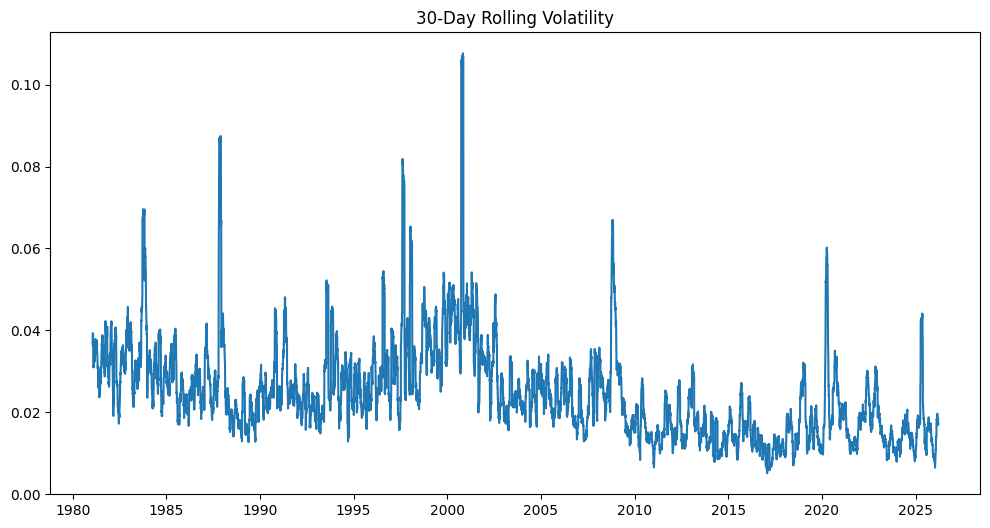

In [10]:
stock_df['volatility'] = stock_df['daily_return'].rolling(30).std()

plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['volatility'])
plt.title("30-Day Rolling Volatility")
plt.show()

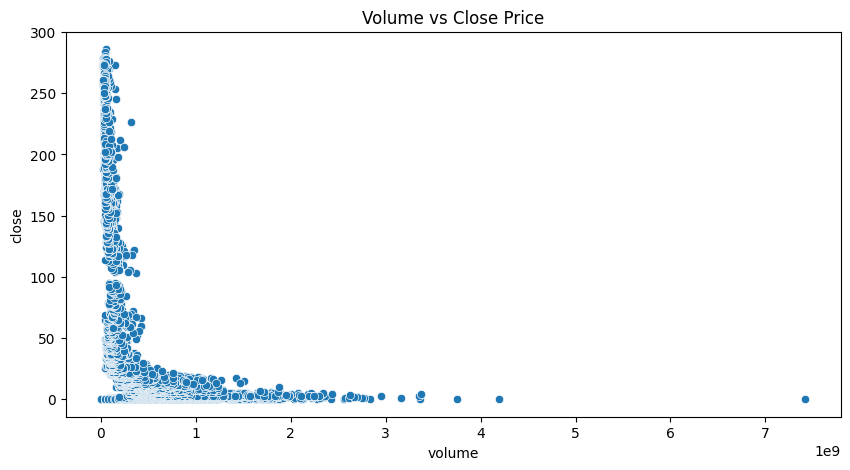

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=stock_df['volume'], y=stock_df['close'])
plt.title("Volume vs Close Price")
plt.show()

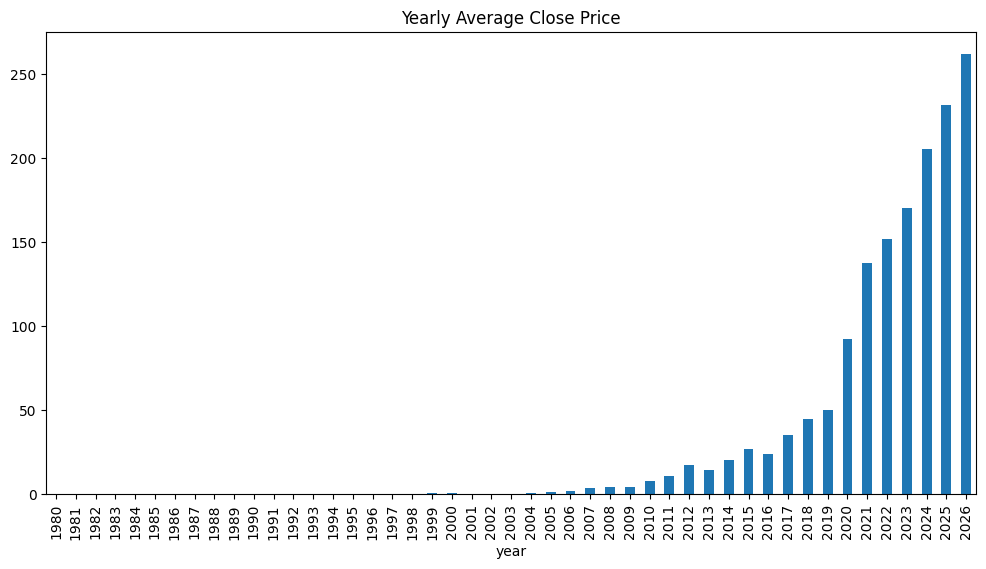

In [12]:
stock_df['year'] = stock_df['date'].dt.year

yearly_avg = stock_df.groupby('year')['close'].mean()

plt.figure(figsize=(12,6))
yearly_avg.plot(kind='bar')
plt.title("Yearly Average Close Price")
plt.show()

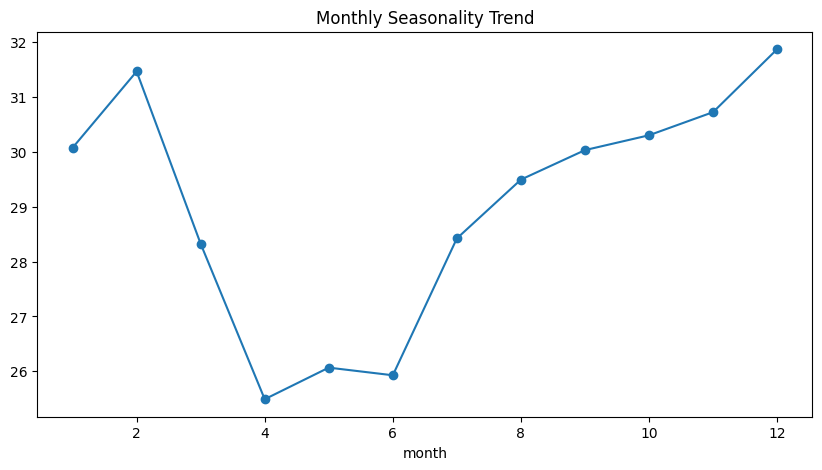

In [13]:
stock_df['month'] = stock_df['date'].dt.month

monthly_avg = stock_df.groupby('month')['close'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='line', marker='o')
plt.title("Monthly Seasonality Trend")
plt.show()

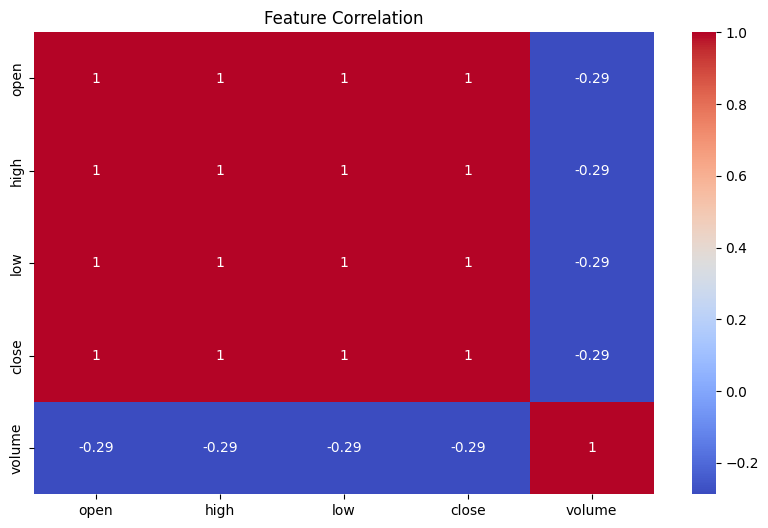

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(stock_df[['open','high','low','close','volume']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

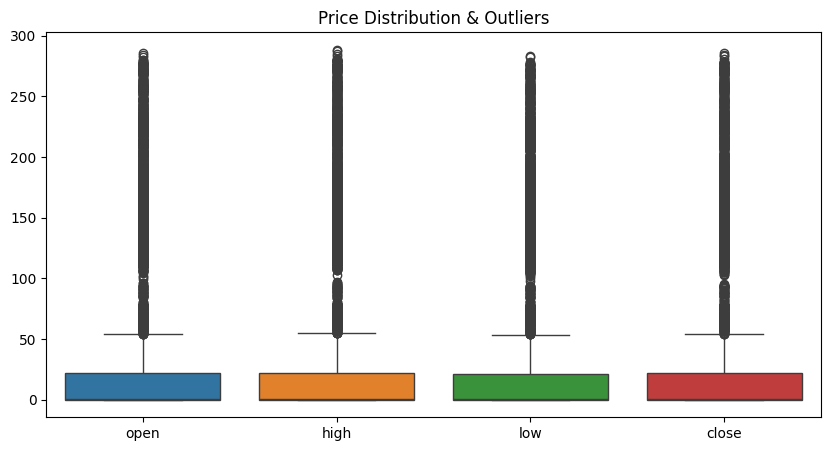

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=stock_df[['open','high','low','close']])
plt.title("Price Distribution & Outliers")
plt.show()

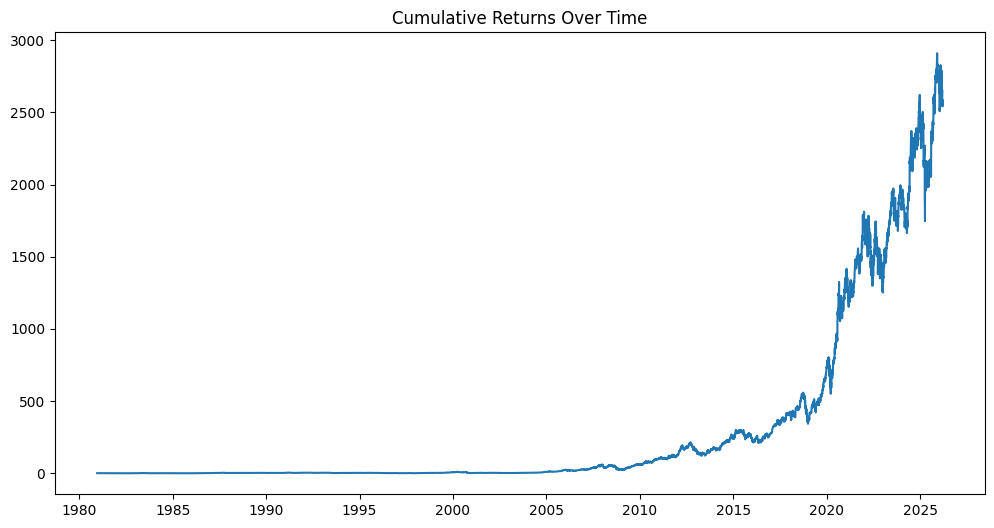

In [16]:
stock_df['cumulative_return'] = (1 + stock_df['daily_return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['cumulative_return'])
plt.title("Cumulative Returns Over Time")
plt.show()

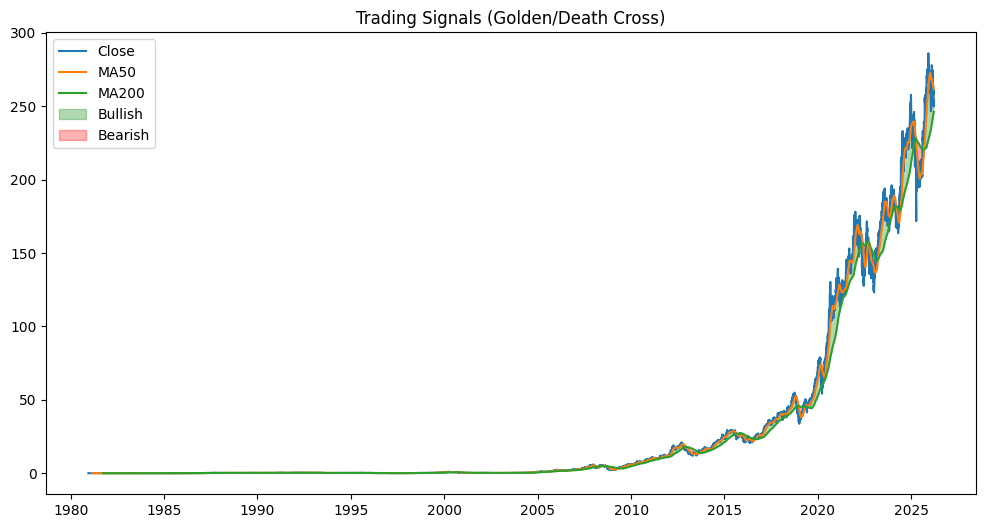

In [17]:
plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['close'], label='Close')
plt.plot(stock_df['date'], stock_df['ma50'], label='MA50')
plt.plot(stock_df['date'], stock_df['ma200'], label='MA200')

# Buy/Sell signal idea
plt.fill_between(stock_df['date'],
                 stock_df['ma50'],
                 stock_df['ma200'],
                 where=(stock_df['ma50'] > stock_df['ma200']),
                 color='green', alpha=0.3, label='Bullish')

plt.fill_between(stock_df['date'],
                 stock_df['ma50'],
                 stock_df['ma200'],
                 where=(stock_df['ma50'] < stock_df['ma200']),
                 color='red', alpha=0.3, label='Bearish')

plt.legend()
plt.title("Trading Signals (Golden/Death Cross)")
plt.show()

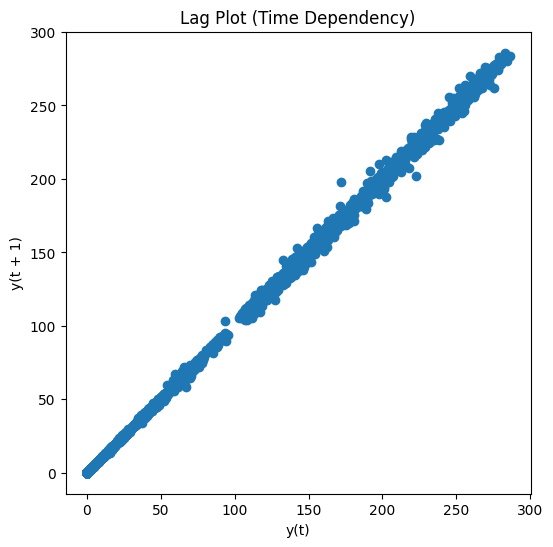

In [18]:
from pandas.plotting import lag_plot

plt.figure(figsize=(6,6))
lag_plot(stock_df['close'])
plt.title("Lag Plot (Time Dependency)")
plt.show()

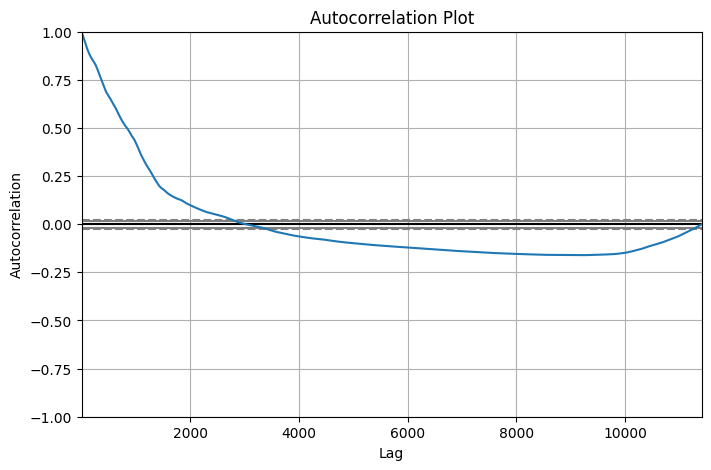

In [19]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(8,5))
autocorrelation_plot(stock_df['close'])
plt.title("Autocorrelation Plot")
plt.show()

## Feature engineering

In [20]:
import os

Random Forest Results
RMSE: 120.74267516574609
R2 Score: -1.8468363080777994


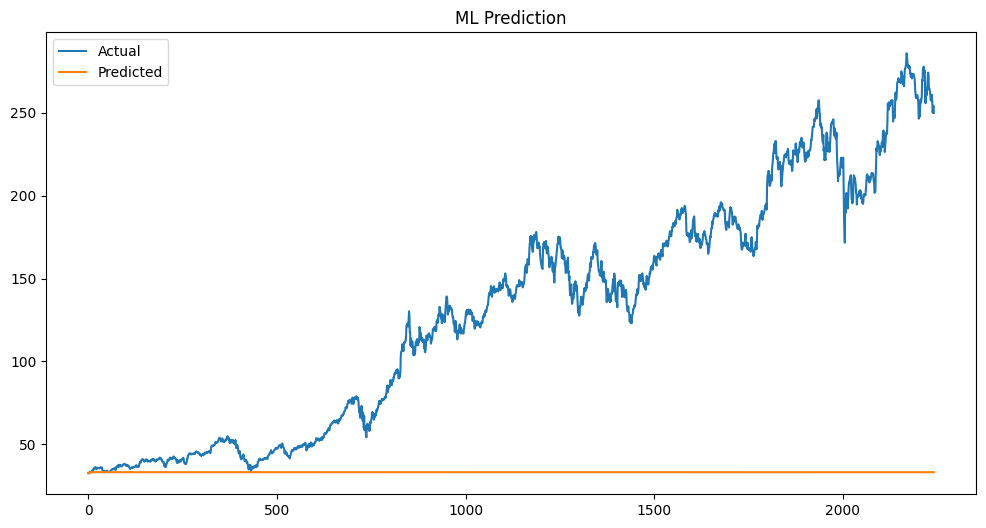

2026-03-27 04:39:59.132171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774586399.352905      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774586399.416169      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774586399.959399      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774586399.959445      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774586399.959449      17 computation_placer.cc:177] computation placer alr

Epoch 1/10


2026-03-27 04:40:24.435702: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 6.5677e-05
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 1.8776e-06
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 1.9700e-06
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 1.7452e-06
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 1.5726e-06
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 1.5623e-06
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - loss: 1.3552e-06
Epoch 8/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 1.1796e-06
Epoch 9/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 1.2436e-06
Epoch 10/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 1.3919e-06
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


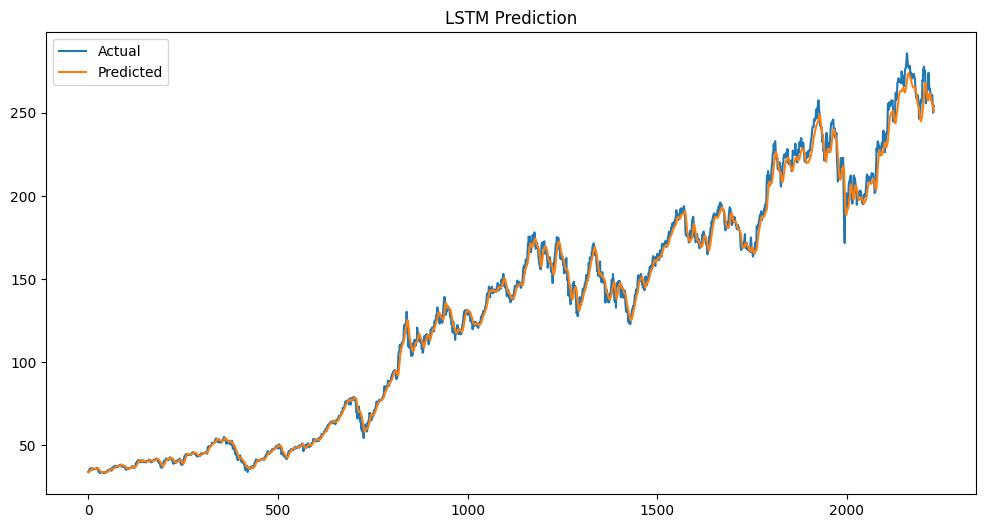


Final Comparison:
Random Forest RMSE: 120.74267516574609
LSTM completed successfully 🚀


In [21]:
# Standardize columns
stock_df.columns = stock_df.columns.str.strip().str.lower()

# Convert date
stock_df['date'] = pd.to_datetime(stock_df['date'])

# Sort
stock_df = stock_df.sort_values('date')

# ================================
# 4. FEATURE ENGINEERING
# ================================
stock_df['daily_return'] = stock_df['close'].pct_change()
stock_df['ma50'] = stock_df['close'].rolling(50).mean()
stock_df['ma200'] = stock_df['close'].rolling(200).mean()
stock_df['volatility'] = stock_df['daily_return'].rolling(30).std()

stock_df.dropna(inplace=True)
# ================================
# 6. ML MODEL (RANDOM FOREST)
# ================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Target
stock_df['target'] = stock_df['close'].shift(-1)
stock_df.dropna(inplace=True)

features = ['open', 'high', 'low', 'volume']
X = stock_df[features]
y = stock_df['target']

# Time-based split
split = int(len(stock_df)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("RMSE:", rmse)
print("R2 Score:", r2)

# Plot predictions
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("ML Prediction")
plt.show()

# ================================
# 7. LSTM MODEL
# ================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Prepare data
data = stock_df[['close']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
X_lstm, y_lstm = [], []
window = 60

for i in range(window, len(data_scaled)):
    X_lstm.append(data_scaled[i-window:i])
    y_lstm.append(data_scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Split
split = int(len(X_lstm)*0.8)
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Build model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(64))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predict
pred = model.predict(X_test)

# Inverse scaling
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("LSTM Prediction")
plt.show()

# ================================
# 8. FINAL OUTPUT
# ================================
print("\nFinal Comparison:")
print("Random Forest RMSE:", rmse)
print("LSTM completed successfully 🚀")